In [18]:
import pandas as pd
import numpy as np
import seaborn as sns
import yaml
from scipy import signal
import matplotlib.patches as patches
import matplotlib.pyplot as plt

In [2]:
datasets = [
    "20260319T0823-tof",
    "20260323T1344-tof",
    "20260320T1036-tysk",
    "20260325T1030-tysk",
    "20260324T1339-it1",
    "20260325T1030-tysk",
    "20260326T0815-tof",
    "20260327T0813-it1",
    "20260327T1030-tysk",
    "20260407T1333-it1",
    "20260408T1034-tysk",
]

skip = 15
grouped = 400

final_dfs = []

for d in datasets:
    with open(f"{d}/meta.yaml") as file:
        meta = yaml.safe_load(file)
    
    dfs = []
    for i in range(meta["Arduinos"]):
        df = pd.read_csv(f"{d}/a{i+1}-data.csv")
        del df["Timestamp"]
        df["Sound"] = df["Sound"].rolling(300).mean()

        # Remove extreme values and the first and last few entries
        df = df.mask(lambda x: x < 2)
        df.loc[df["Humidity (%)"] > 90, "Humidity (%)"] = np.nan
        df.loc[df["Temperature (C)"] > 25, "Temperature (C)"] = np.nan
        df.loc[df["Temperature (C)"] < 15, "Temperature (C)"] = np.nan

        # Align all dataframes with the first one
        if i > 1:
            parameter = "Light"
            sig1 = dfs[0][parameter] - dfs[0][parameter].mean()
            sig2 = df[parameter] - df[parameter].mean()
            corr = signal.correlate(sig1, sig2, mode="full")
            lags = signal.correlation_lags(len(sig1), len(sig2), mode="full")
            best_lag = lags[np.argmad(corr)]
            df = df.shift(periods=best_lag)

        df = df[skip:-skip].copy()
        df = df.dropna()
        dfs.append(df)
    del meta["Arduinos"]

    df = pd.concat(dfs)
    df = df.groupby(df.index).mean()
    df = df.groupby(np.arange(len(df)) // grouped).mean()

    survey = pd.read_csv(f"{d}/survey.csv", header=0, names=["Timestamp", "Concentration", "Work"])
    del survey["Timestamp"]
    for col, mean in survey.mean().items():
        df[col] = mean

    for col, val in meta.items():
        df[col] = val
    
    final_dfs.append(df)

df = pd.concat(final_dfs)
df = df.reset_index(drop=True)


In [3]:
df

,Temperature (C),Humidity (%),Sound,Light,Concentration,Work,Room,Subject
0,20.240900,39.726887,14099.058497,343.203750,3.625,3.125,619,tof
1,20.293725,39.692975,14586.702854,354.790000,3.625,3.125,619,tof
2,20.718450,38.934550,14746.194211,462.815000,3.625,3.125,619,tof
3,21.590025,37.248125,12628.208850,361.322500,3.625,3.125,619,tof
4,21.684225,36.954975,14432.631770,363.047500,3.625,3.125,619,tof
...,...,...,...,...,...,...,...,...
65,21.487300,17.995375,11571.432117,941.421250,3.250,2.250,413,tysk
66,21.589563,19.885763,20442.283288,898.950000,3.250,2.250,413,tysk
67,21.770850,20.758925,22617.275807,841.151250,3.250,2.250,413,tysk
68,21.887250,20.654500,26673.679037,921.512500,3.250,2.250,413,tysk


<Axes: >

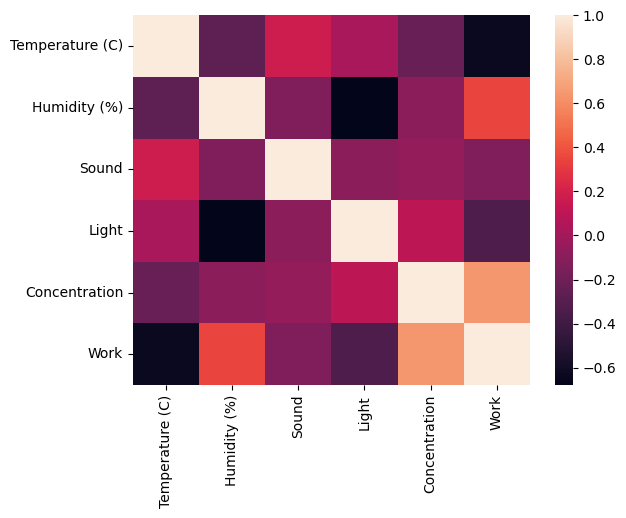

In [6]:
corr = df.corr(numeric_only=True)
sns.heatmap(corr)

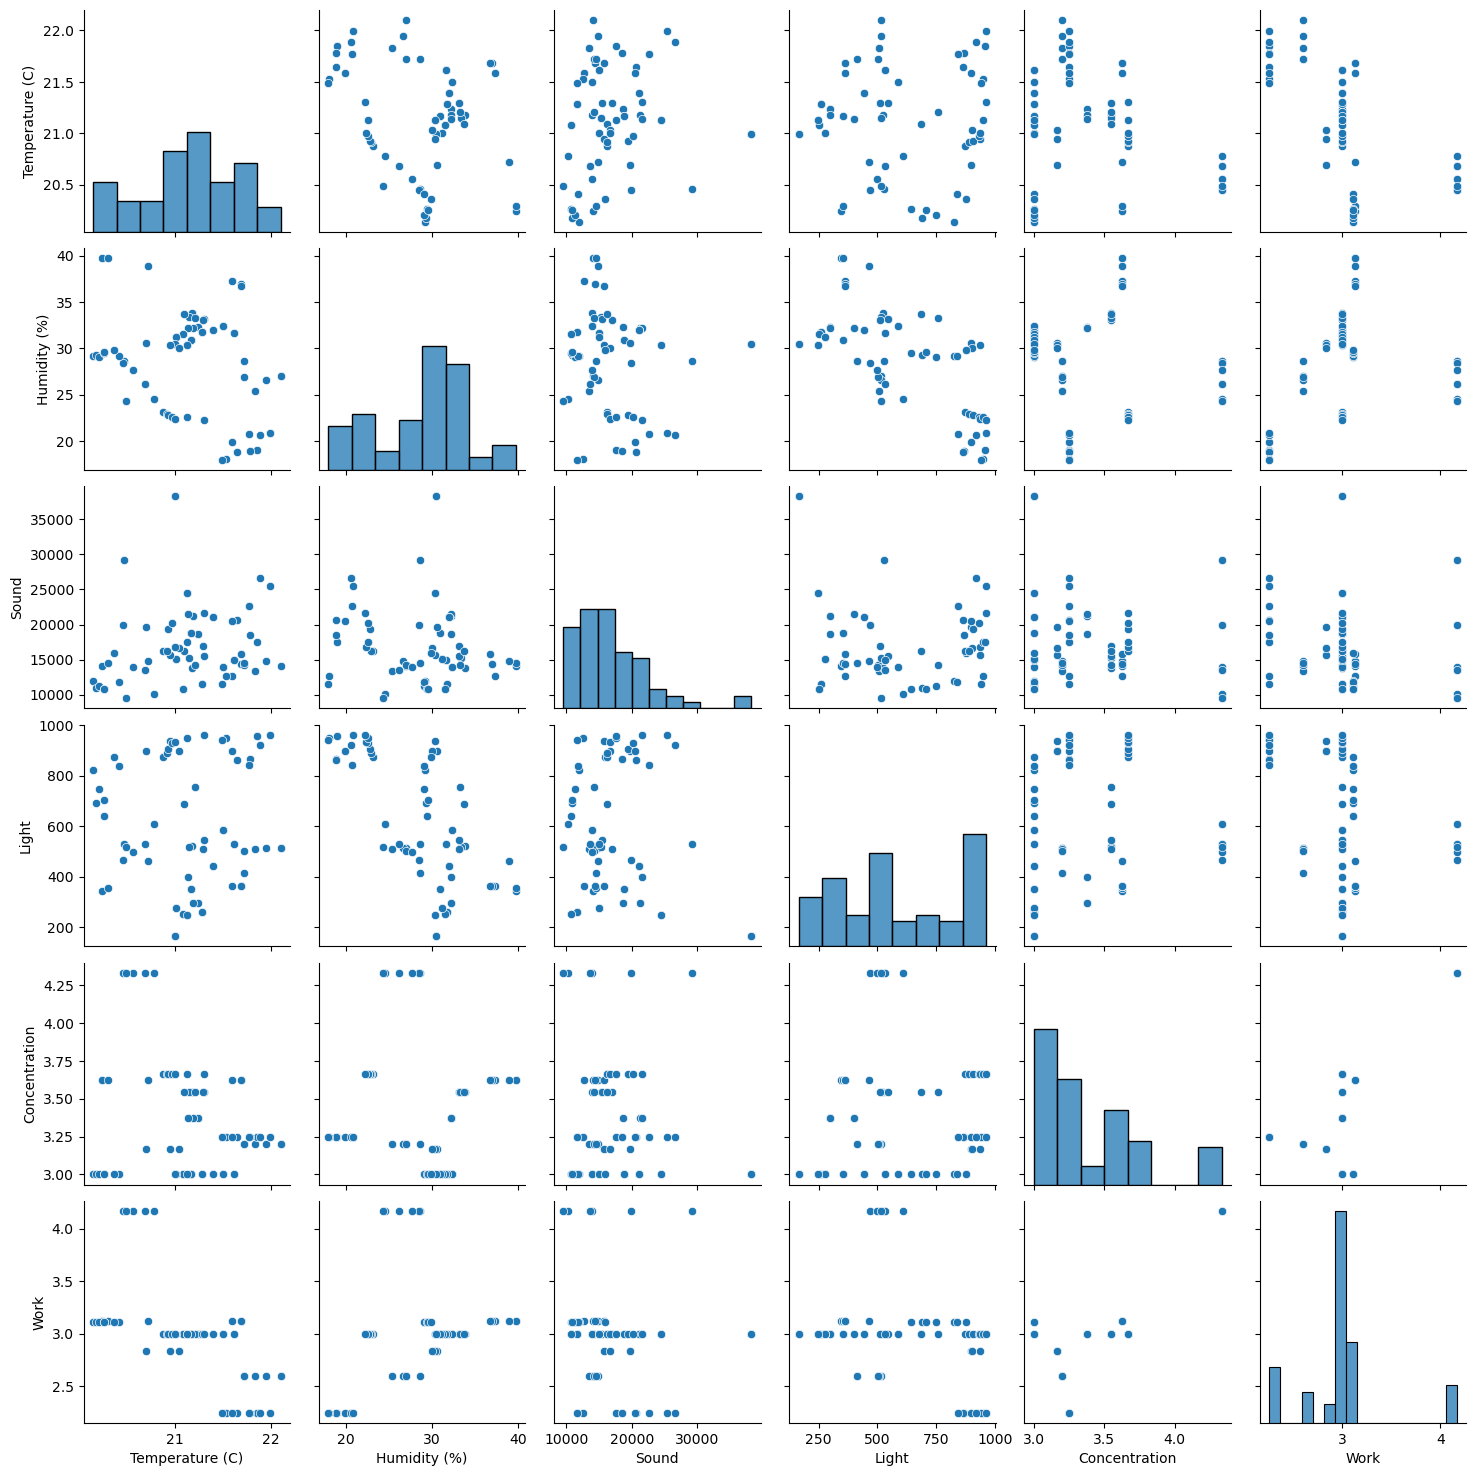

In [5]:
sns.pairplot(df)

<Axes: >

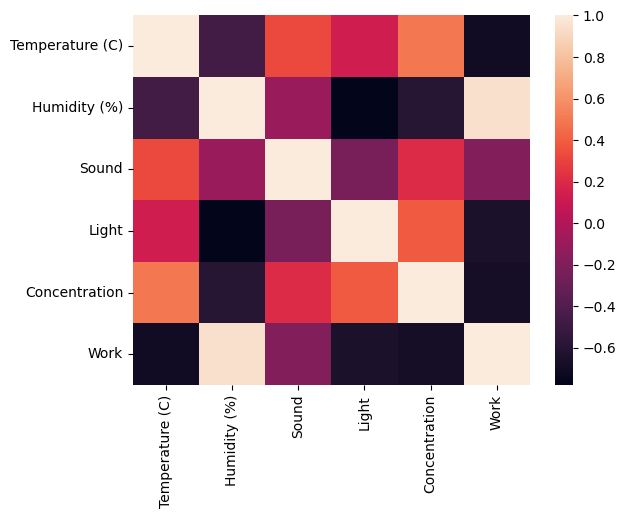

In [13]:
#| label: tysk-corr
corr = df[df["Subject"] == "tysk"].corr(numeric_only=True)
sns.heatmap(corr)

<Axes: >

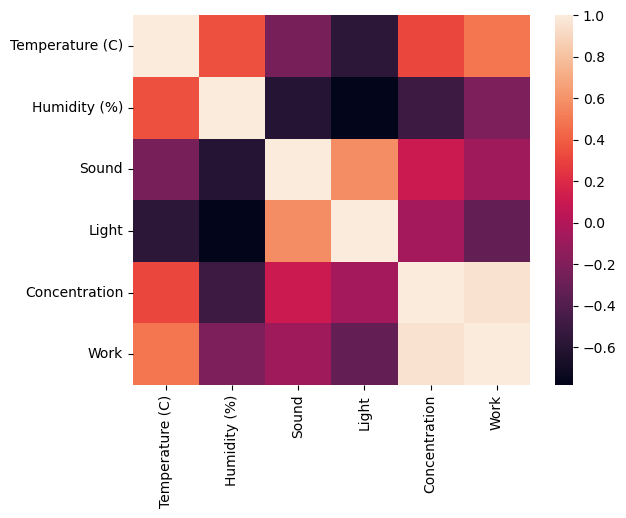

In [15]:
#| label: it1-corr
corr = df[df["Subject"] == "it1"].corr(numeric_only=True)
sns.heatmap(corr)

<Axes: >

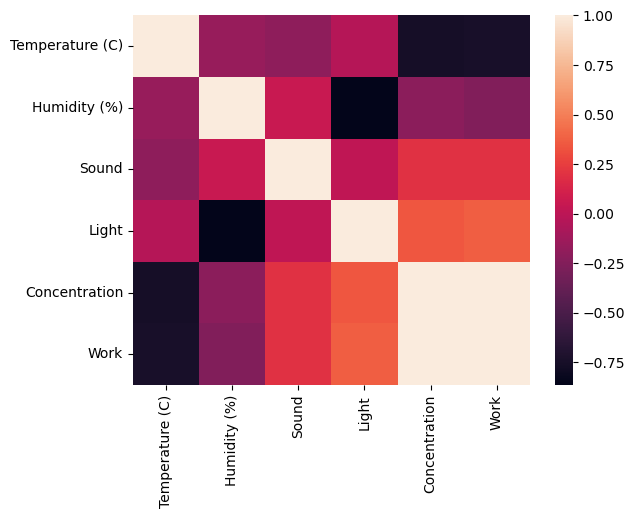

In [16]:
#| label: tof-corr
corr = df[df["Subject"] == "tof"].corr(numeric_only=True)
sns.heatmap(corr)

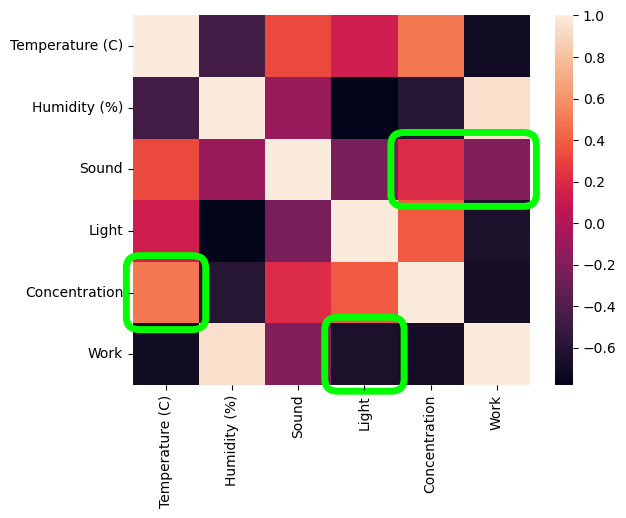

In [57]:
#| label: tysk-corr2
corr = df[df["Subject"] == "tysk"].corr(numeric_only=True)
ax = sns.heatmap(corr)

def highlight(y, x):
    circle = patches.Circle((x + 0.5, y + 0.5), radius=0.7, 
                        edgecolor='#00FF00', facecolor='none', lw=4)
    ax.add_patch(circle)

#highlight(2, 4)

def highlight2(x, y, h, w):
    d = 0.1
    rect = patches.FancyBboxPatch((x-d, y-d), w+2*d, h+2*d, edgecolor='#00FF00', facecolor='none', lw=5, clip_on=False, boxstyle="round,pad=0,rounding_size=0.2",)
    ax.add_patch(rect)

highlight2(4, 2, 1, 2)
highlight2(0, 4, 1, 1)
highlight2(3, 5, 1, 1)

plt.show()

In [7]:
df["Subject"].value_counts()

Subject
tysk    37
tof     17
it1     16
Name: count, dtype: int64

In [8]:
df[df["Subject"] == "tysk"]

,Temperature (C),Humidity (%),Sound,Light,Concentration,Work,Room,Subject
11,21.234575,32.258688,18716.089628,297.312500,3.375,3.000000,413,tysk
12,21.181787,32.243063,21227.865143,296.258750,3.375,3.000000,413,tysk
13,21.138707,32.243401,21541.680179,399.346939,3.375,3.000000,413,tysk
14,21.392200,31.932900,21075.310893,440.943750,3.000,3.000000,413,tysk
15,21.503612,32.367638,13951.790217,585.311250,3.000,3.000000,413,tysk
16,21.618550,31.645937,14942.691251,530.170000,3.000,3.000000,413,tysk
17,21.284862,31.727812,11542.919877,261.547500,3.000,3.000000,413,tysk
18,21.079487,31.540613,10747.215229,251.771250,3.000,3.000000,413,tysk
19,21.008225,31.211262,15031.347797,275.310000,3.000,3.000000,413,tysk
20,21.165563,30.934700,18784.883581,351.561250,3.000,3.000000,413,tysk


In [9]:
df[df["Subject"] == "tof"]

,Temperature (C),Humidity (%),Sound,Light,Concentration,Work,Room,Subject
0,20.240900,39.726887,14099.058497,343.203750,3.625000,3.125000,619,tof
1,20.293725,39.692975,14586.702854,354.790000,3.625000,3.125000,619,tof
2,20.718450,38.934550,14746.194211,462.815000,3.625000,3.125000,619,tof
3,21.590025,37.248125,12628.208850,361.322500,3.625000,3.125000,619,tof
4,21.684225,36.954975,14432.631770,363.047500,3.625000,3.125000,619,tof
5,21.684286,36.759549,15754.596687,362.390977,3.625000,3.125000,619,tof
6,22.101700,27.053800,14044.582219,513.380000,3.200000,2.600000,619,tof
7,21.942700,26.650950,14822.636272,515.918750,3.200000,2.600000,619,tof
8,21.831887,25.405738,13423.095510,508.445000,3.200000,2.600000,619,tof
9,21.722550,26.943638,14236.159928,503.982500,3.200000,2.600000,619,tof


In [10]:
df[df["Subject"] == "it1"]

,Temperature (C),Humidity (%),Sound,Light,Concentration,Work,Room,Subject
23,21.178663,33.784450,13859.522287,522.930000,3.545455,3.000000,413,it1
24,21.147950,33.346412,15293.647400,517.001250,3.545455,3.000000,413,it1
25,21.296700,33.168337,15447.601376,545.128750,3.545455,3.000000,413,it1
26,21.290825,33.115575,16975.336716,511.530000,3.545455,3.000000,413,it1
27,21.208263,33.265425,14165.812594,756.212500,3.545455,3.000000,413,it1
28,21.092253,33.721019,16187.096553,687.021605,3.545455,3.000000,413,it1
44,20.694288,30.600662,19697.729257,898.788750,3.166667,2.833333,413,it1
45,20.949725,30.404163,15708.459501,938.675000,3.166667,2.833333,413,it1
46,21.037003,30.019675,16681.683570,900.470890,3.166667,2.833333,413,it1
54,20.873738,23.136188,16255.240828,873.481250,3.666667,3.000000,413,it1


<Axes: >

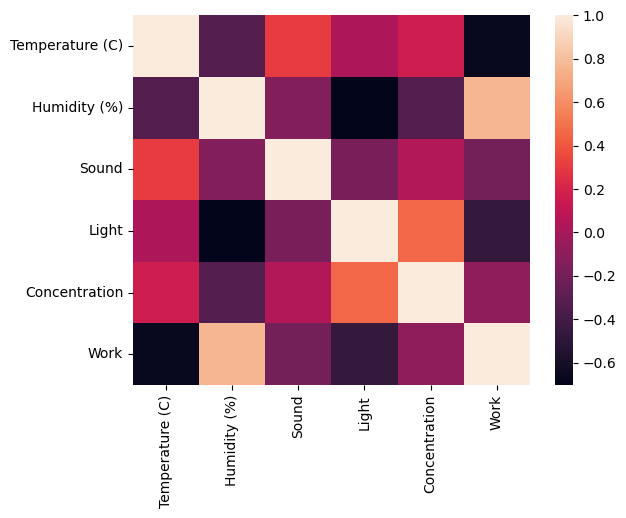

In [11]:
corr = df[df["Room"] == "413"].corr(numeric_only=True)
sns.heatmap(corr)

In [12]:
final_dfs = []

for d in datasets:
    with open(f"{d}/meta.yaml") as file:
        meta = yaml.safe_load(file)
    del meta["Arduinos"]
    survey = pd.read_csv(f"{d}/survey.csv", header=0, names=["Timestamp", "Concentration", "Work"])
    del survey["Timestamp"]
    for col, val in meta.items():
        survey[col] = val
    
    final_dfs.append(survey)

df = pd.concat(final_dfs)
df = df.reset_index(drop=True)

In [13]:
df

,Concentration,Work,Room,Subject
0,3,5,619,tof
1,4,2,619,tof
2,3,1,619,tof
3,4,3,619,tof
4,5,4,619,tof
...,...,...,...,...
76,4,3,413,it1
77,5,4,413,tysk
78,3,1,413,tysk
79,3,3,413,tysk


In [14]:
df["Concentration"].value_counts()

Concentration
4    32
3    25
2    12
5    10
1     2
Name: count, dtype: int64

In [15]:
df["Work"].value_counts()

Work
3    26
4    20
2    17
5     9
1     9
Name: count, dtype: int64

In [16]:
df[df["Subject"] == "tysk"]["Concentration"].value_counts()

Concentration
4    12
2     9
3     8
5     3
1     1
Name: count, dtype: int64

In [17]:
df[df["Subject"] == "tof"]["Concentration"].value_counts()

Concentration
4    9
3    4
5    4
2    1
1    1
Name: count, dtype: int64

In [18]:
df[df["Subject"] == "it1"]["Concentration"].value_counts()

Concentration
3    13
4    11
5     3
2     2
Name: count, dtype: int64

In [19]:
df[df["Subject"] == "tysk"]["Work"].value_counts()

Work
4    12
3     7
2     6
1     6
5     2
Name: count, dtype: int64

In [20]:
df[df["Subject"] == "tof"]["Work"].value_counts()

Work
5    6
3    5
2    4
1    2
4    2
Name: count, dtype: int64

In [21]:
df[df["Subject"] == "it1"]["Work"].value_counts()

Work
3    14
2     7
4     6
5     1
1     1
Name: count, dtype: int64

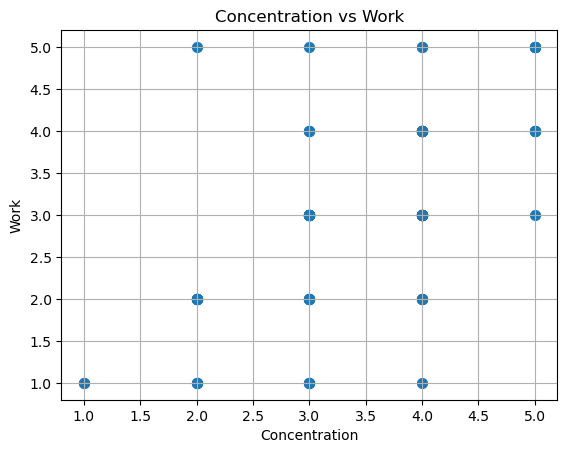

In [22]:
import matplotlib.pyplot as plt
plt.scatter(df["Concentration"], df["Work"], s=50)
plt.xlabel("Concentration")
plt.ylabel("Work")
plt.title("Concentration vs Work")
plt.grid()
plt.show()

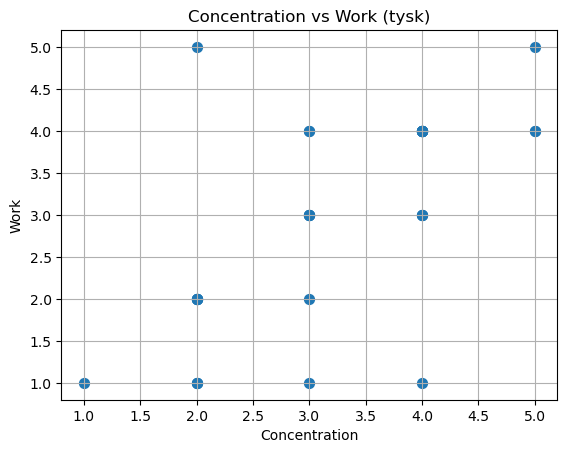

In [23]:
import matplotlib.pyplot as plt
plt.scatter(df[df["Subject"] == "tysk"]["Concentration"], df[df["Subject"] == "tysk"]["Work"], s=50)
plt.xlabel("Concentration")
plt.ylabel("Work")
plt.title("Concentration vs Work (tysk)")
plt.grid()
plt.show()

Cronbach alpha:

≥ 0.7 → acceptable reliability

≥ 0.8 → good

In [24]:
import numpy as np

def cronbach_alpha(df_subset):
    items = df_subset.dropna()
    item_vars = items.var(axis=0, ddof=1)
    total_var = items.sum(axis=1).var(ddof=1)
    n_items = items.shape[1]
    return (n_items / (n_items - 1)) * (1 - item_vars.sum() / total_var)

cronbach_alpha(df[['Concentration','Work']])

np.float64(0.768319763138416)

In [25]:
cronbach_alpha(df[df["Subject"] == "tysk"][['Concentration','Work']])

np.float64(0.7821953327571307)

In [26]:
cronbach_alpha(df[df["Subject"] == "tof"][['Concentration','Work']])

np.float64(0.745562130177515)

In [27]:
cronbach_alpha(df[df["Subject"] == "it1"][['Concentration','Work']])

np.float64(0.7522522522522523)

In [28]:
df.describe()

,Concentration,Work
count,81.000000,81.000000
mean,3.444444,3.037037
std,0.974679,1.166667
min,1.000000,1.000000
25%,3.000000,2.000000
50%,4.000000,3.000000
75%,4.000000,4.000000
max,5.000000,5.000000


In [29]:
df[df["Subject"] == "tysk"].describe()

,Concentration,Work
count,33.000000,33.000000
mean,3.212121,2.939394
std,1.053493,1.248484
min,1.000000,1.000000
25%,2.000000,2.000000
50%,3.000000,3.000000
75%,4.000000,4.000000
max,5.000000,5.000000


In [30]:
df["row_std"] = df[["Concentration", "Work"]].std(axis=1)

In [31]:
df.groupby("Subject")["row_std"].describe()

,count,mean,std,min,25%,50%,75%,max
Subject,,,,,,,,
it1,29.0,0.438894,0.478606,0.0,0.0,0.707107,0.707107,1.414214
tof,19.0,0.595458,0.589876,0.0,0.0,0.707107,1.060660,1.414214
tysk,33.0,0.407122,0.587109,0.0,0.0,0.000000,0.707107,2.121320


In [32]:
df["Subject"].value_counts()

Subject
tysk    33
it1     29
tof     19
Name: count, dtype: int64

In [33]:
df.groupby("Subject")[["Concentration", "Work"]].corr(numeric_only=True)

Concentration      Work
Subject                                       
it1     Concentration       1.000000  0.605773
        Work                0.605773  1.000000
tof     Concentration       1.000000  0.621889
        Work                0.621889  1.000000
tysk    Concentration       1.000000  0.651583
        Work                0.651583  1.000000